# 🔹 Final Model for Dog Sound Classification for a specific breed

This section creates and saves all the parameters required to use the trained model later, including the model itself, preprocessing statistics, and the label encoder.


In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from IPython.display import Audio

import torchaudio
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import opensmile
from tqdm import tqdm
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

# 🔹 Dataset Loading
- Load all audio file paths and their corresponding labels from the dataset.
- Each subdirectory represents a different label (dog breed).
- Collect file paths and assign labels based on folder names.
- Store results in a DataFrame for further processing.

In [ ]:
razza = "chihuahua"

dirRazza = razza[0].upper() + razza[1:]

base_dir = f'D:\Scuola\TESI-2025\Mescalina2017_sorted\{dirRazza}\sounds'

paths = []
labels = []

for dirname, _, filenames in os.walk(base_dir):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        paths.append(file_path)
        label = os.path.basename(dirname)
        labels.append(label)
print('Dataset is Loaded')

df = pd.DataFrame({"audio_paths": paths, "labels": labels})
print(df.head())
print(df['labels'].value_counts())
print(f"\nTotale file: {len(df)}, razze: {df['labels'].nunique()}")

Dataset is Loaded
                                         audio_paths labels
0  D:\Scuola\TESI-2025\Mescalina2017_sorted\Chihu...  B-AGR
1  D:\Scuola\TESI-2025\Mescalina2017_sorted\Chihu...  B-AGR
2  D:\Scuola\TESI-2025\Mescalina2017_sorted\Chihu...  B-AGR
3  D:\Scuola\TESI-2025\Mescalina2017_sorted\Chihu...  B-AGR
4  D:\Scuola\TESI-2025\Mescalina2017_sorted\Chihu...  B-AGR
labels
B-AGR     1745
B-NEU     1222
B-OWN      469
G-NEG      397
B-ANX      147
W-NEG      143
W-POS       44
B-FEAR      28
B-WLK       24
B-PLY       12
G-POS       11
B-HOM       10
B-OTH        8
Name: count, dtype: int64

Totale file: 4260, razze: 13


# 🔹 Data Filtering
- Count files per label.
- Keep only labels with a minimum number of files (e.g., 80 or 100).
- Subset the DataFrame to ensure balanced representation per label.
- Visualize label distribution.

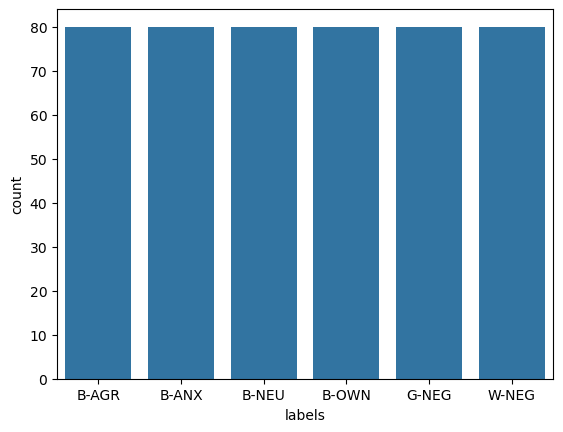

In [ ]:
MIN_FILES = 80

label_counts = df['labels'].value_counts()

valid_labels = label_counts[label_counts >= MIN_FILES].index

filtered_df = df[df['labels'].isin(valid_labels)]

df = filtered_df.groupby('labels').head(MIN_FILES).reset_index(drop=True)

sns.countplot(x='labels', data=df)
plt.show()

label_counts = df['labels'].value_counts()
valid_labels = label_counts[label_counts >= MIN_FILES].index
filtered_df = df[df['labels'].isin(valid_labels)]
df = filtered_df.groupby('labels').head(MIN_FILES).reset_index(drop=True)

# 🔹 Feature Extraction Utilities

- **`load_paths(file_path)`**  
  Reads a text file containing one audio file path per line and returns a list of cleaned paths.

- **`extract_lld_features(audio_path)`**  
  Extracts Low-Level Descriptors (LLDs) from an audio file using the `ComParE_2016` feature set provided by `openSMILE`.  
  Returns a NumPy array of extracted features.


In [5]:
def load_paths(file_path):
    with open(file_path) as f:
        return [line.strip() for line in f]
    
def extract_lld_features(audio_path):
    """Estrae LLD e applica padding se necessario"""
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.ComParE_2016,
        feature_level=opensmile.FeatureLevel.LowLevelDescriptors
    )
    features = smile.process_file(audio_path).values
    return features 

# 🔹 Data Preparation Using Predefined Splits

This section prepares the training, validation, and test sets using pre-defined split files.

## 🗂️ Workflow

- Uses a fixed `seed = 1` and builds the corresponding split directory path.
- Loads audio paths for:
  - Training (`train.txt`)
  - Validation (`val.txt`)
  - Testing (`test.txt`)
- Filters the main DataFrame `df` to create:
  - `train_df`: samples matching `train.txt`
  - `val_df`: samples matching `val.txt`
  - `test_df`: samples matching `test.txt`
- Resets indices of the resulting DataFrames for clean iteration.

## ✅ Output

- Displays the number of samples in each split.
- Ensures consistency across experiments using fixed splits.


In [ ]:
seed = 1

seed_dir = os.path.join(f"split_lists/{razza}", f"seed_test")

train_paths = load_paths(os.path.join(seed_dir, "train.txt"))
val_paths = load_paths(os.path.join(seed_dir, "val.txt"))
test_paths = load_paths(os.path.join(seed_dir, "test.txt"))

train_df = df[df['audio_paths'].isin(train_paths)].reset_index(drop=True)
val_df = df[df['audio_paths'].isin(val_paths)].reset_index(drop=True)
test_df = df[df['audio_paths'].isin(test_paths)].reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 335, Val: 69, Test: 76


# 🔹 LLD Feature Extraction

This section performs feature extraction using Low-Level Descriptors (LLDs) for each audio file.

## 🔧 Process

- Applies the `extract_lld_features()` function to all audio files in the training, validation, and test sets.
- Uses `opensmile` with the `ComParE_2016` feature set and `LowLevelDescriptors` level.
- Wraps the extraction in `tqdm` to provide a progress bar for monitoring the extraction process.

## 📦 Output

- `train_sequences`: list of LLD feature arrays for training audio files.
- `val_sequences`: list for validation files.
- `test_sequences`: list for test files.

These sequences will be used for further preprocessing, including padding and normalization.


In [17]:
print("Estrazione feature LLD...")
train_sequences = [extract_lld_features(path) for path in tqdm(train_df['audio_paths'])]
val_sequences = [extract_lld_features(path) for path in tqdm(val_df['audio_paths'])]
test_sequences = [extract_lld_features(path) for path in tqdm(test_df['audio_paths'])]

Estrazione feature LLD...


100%|██████████| 76/76 [00:08<00:00,  8.47it/s]


# 🔹 Sequence Padding and Dimension Setup

This section prepares the feature sequences for model training by unifying their lengths and determining dimensionality.

## 🔧 Steps

- **Maximum Length Calculation**:  
  Determines `max_len` as the length of the longest feature sequence across training, validation, and test sets.

- **Feature Count**:  
  Retrieves the number of features per frame (`n_features`) from the first training sequence.

- **Padding Sequences**:  
  Applies `post` padding and truncation using `pad_sequences()` to ensure all sequences have the same length (`max_len`).  
  Padding is applied separately for training, validation, and test sets.

## 📦 Output Shapes

The final shapes of the feature arrays are printed:
- `X_train`: shape `(num_train_samples, max_len, n_features)`
- `X_val`: shape `(num_val_samples, max_len, n_features)`
- `X_test`: shape `(num_test_samples, max_len, n_features)`

These padded arrays are now ready for input into the model.


In [ ]:

max_len = max(seq.shape[0] for seq in train_sequences + val_sequences + test_sequences)
n_features = train_sequences[0].shape[1] 

X_train = pad_sequences(train_sequences, maxlen=max_len, dtype='float32', padding='post', truncating='post')
X_val = pad_sequences(val_sequences, maxlen=max_len, dtype='float32', padding='post', truncating='post')
X_test = pad_sequences(test_sequences, maxlen=max_len, dtype='float32', padding='post', truncating='post')

print(f"Shape finale: {X_train.shape} (samples x timesteps x features)")
print(f"Shape finale: {X_val.shape} (samples x timesteps x features)")
print(f"Shape finale: {X_test.shape} (samples x timesteps x features)")

Shape finale: (335, 739, 65) (samples x timesteps x features)
Shape finale: (69, 739, 65) (samples x timesteps x features)
Shape finale: (76, 739, 65) (samples x timesteps x features)


# 🔹 Audio Sequence Preprocessing

## 📏 Maximum Sequence Length and Number of Features
The maximum length among all extracted sequences and the number of features per frame are determined to standardize the shape of the data for the neural network.

## 🧩 Sequence Padding
Audio sequences are padded post-fix to reach the maximum length, ensuring that all sequences have the same dimensions.

## 🏷️ Label Encoding
The data labels are converted into integer values using `LabelEncoder`, making them compatible with neural network classification.

## ⚖️ Feature Normalization
Features are normalized by subtracting the mean and dividing by the standard deviation calculated on the training set. This helps the model converge faster.

## 🔄 Reshape for CNN
The data is reshaped into a 4-dimensional format `(samples, timesteps, features, channels)` to be compatible with the input required by convolutional neural networks.

## ✅ Final Dimension Check
The final shapes of `X_train`, `X_val`, `X_test` and the target vectors `y_train`, `y_val`, `y_test` are verified to ensure correctness before training the model.


In [21]:
max_len = max(seq.shape[0] for seq in train_sequences + val_sequences + test_sequences)
n_features = train_sequences[0].shape[1]

X_train = pad_sequences(train_sequences, maxlen=max_len, dtype='float32', padding='post')
X_val = pad_sequences(val_sequences, maxlen=max_len, dtype='float32', padding='post')
X_test = pad_sequences(test_sequences, maxlen=max_len, dtype='float32', padding='post')

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['labels'])
y_val = label_encoder.transform(val_df['labels'])
y_test = label_encoder.transform(test_df['labels'])

mean = X_train.mean(axis=(0,1))
std = X_train.std(axis=(0,1))
X_train = (X_train - mean) / (std + 1e-8)
X_val = (X_val - mean) / (std + 1e-8)
X_test = (X_test - mean) / (std + 1e-8)

X_train = X_train.reshape(-1, max_len, n_features, 1)
X_val = X_val.reshape(-1, max_len, n_features, 1)
X_test = X_test.reshape(-1, max_len, n_features, 1)

# 🔹 CNN Model Architecture

## 🏗️ Model Layers
- **Input Layer**: Accepts sequences with shape `(2225, 65)`, where `2225` is the number of timesteps and `65` is the number of features per timestep.
- **Conv1D Layer 1**: 64 filters, kernel size 3, ReLU activation, same padding.
- **MaxPooling1D Layer 1**: Pool size 2 to reduce temporal dimension.
- **Conv1D Layer 2**: 128 filters, kernel size 3, ReLU activation, same padding.
- **MaxPooling1D Layer 2**: Pool size 2 for further temporal reduction.
- **GlobalAveragePooling1D**: Reduces the sequence dimension by averaging, producing a fixed-length feature vector.
- **Dense Output Layer**: Number of units equals the number of unique classes, with softmax activation for classification.

## ⚙️ Compilation
- **Optimizer**: Adam with the best learning rate for the breed.
- **Loss Function**: Sparse categorical crossentropy.
- **Metrics**: Accuracy.

## 📝 Summary
The model is designed to process padded sequences of audio features and perform multi-class classification, reducing overfitting with pooling and producing class probabilities using softmax.


In [27]:
model = models.Sequential([
    layers.Input(shape=(2225, 65)),
    layers.Conv1D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.GlobalAveragePooling1D(),
    layers.Dense(len(np.unique(y_train)), activation='softmax')
])


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 2225, 64)       │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 1112, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1112, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 556, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,022 (148.52 KB)

 Trainable params: 38,022 (148.52 KB)

 Non-trainable params: 0 (0.00 B)

# 🔹 Model Training

## 🏋️ Training Configuration
- **Training Data**: `X_train` with labels `y_train`.
- **Validation Data**: `X_val` with labels `y_val`.
- **Epochs**: 100 iterations over the entire training set.
- **Batch Size**: based on the optimal batch size for the breed.

## ⚡ Training Process
The model iteratively updates its weights using the Adam optimizer. After each epoch, it evaluates performance on the validation set to monitor generalization and detect overfitting.

## 📊 Output
The `history` object stores:
- Training accuracy and loss per epoch.
- Validation accuracy and loss per epoch.
- Useful for plotting learning curves and analyzing model performance over time.


In [28]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.2199 - loss: 2.0646 - val_accuracy: 0.5362 - val_loss: 1.4454
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5091 - loss: 1.2514 - val_accuracy: 0.6522 - val_loss: 1.0805
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.6251 - loss: 1.0041 - val_accuracy: 0.6957 - val_loss: 0.8936
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6654 - loss: 0.8297 - val_accuracy: 0.6522 - val_loss: 0.9533
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.7595 - loss: 0.6675 - val_accuracy: 0.7681 - val_loss: 0.8350
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7893 - loss: 0.6083 - val_accuracy: 0.7391 - val_loss: 0.8177
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7650 - loss: 0.6707 - val_accuracy: 0.7536 - val_loss: 0.6750
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7565 - loss: 0.6390 - val_accuracy: 0.

# 🔹 Model Evaluation and Visualization

## 📈 Accuracy and Loss Curves
- Plot the training and validation accuracy per epoch.
- Plot the training and validation loss per epoch.
- Helps to identify overfitting or underfitting trends.

## 🧪 Test Set Evaluation
- Evaluate the model on `X_test` and `y_test`.
- Outputs **Test Loss** and **Test Accuracy**.

## 📝 Classification Metrics
- Generate predictions on the test set.
- Compute the **Classification Report**: precision, recall, F1-score for each class.

## 🔹 Confusion Matrix
- Normalize the confusion matrix to show proportions.
- Visualize it with a heatmap using Seaborn.
- Allows easy inspection of misclassifications and class-level performance.


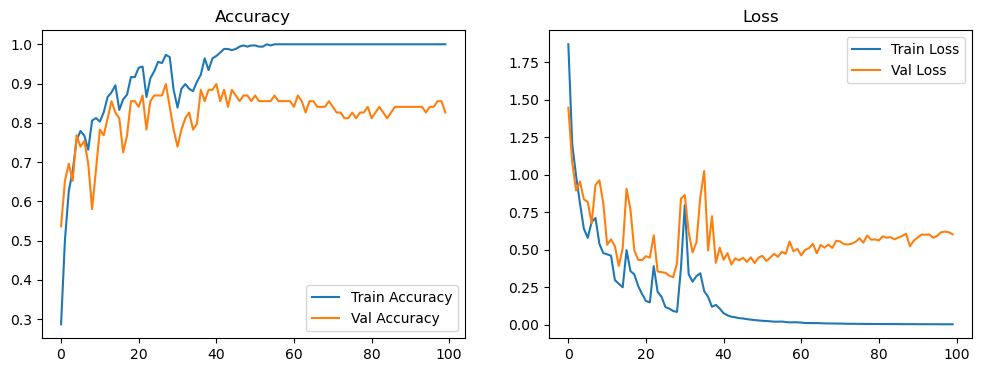

3/3 - 0s - 27ms/step - accuracy: 0.9211 - loss: 0.7830

Test Accuracy: 0.9211
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        11
           1       0.86      1.00      0.92        12
           2       1.00      0.91      0.95        11
           3       1.00      0.93      0.97        15
           4       0.93      0.87      0.90        15
           5       0.91      0.83      0.87        12

    accuracy                           0.92        76
   macro avg       0.92      0.92      0.92        76
weighted avg       0.93      0.92      0.92        76



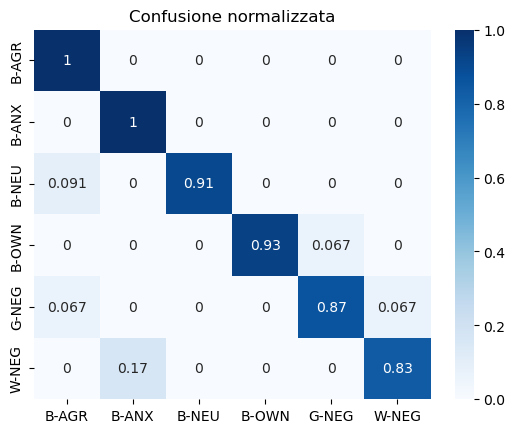

In [29]:
# Grafico accuracy e loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")

y_pred = model.predict(X_test).argmax(axis=1)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, cmap='Blues')
plt.title("Confusione normalizzata")
plt.show()

# 🔹 Saving Model and Preprocessing Artifacts

## 🏗️ Save Trained Model
- Save the trained model in HDF5 format for later use.
- Example path: `best_model_razza.h5`.

## ⚙️ Save Preprocessing Parameters
- Save normalization parameters (`mean`, `std`) and sequence info (`max_len`, `n_features`) in a `.npz` file.
- Ensures consistent preprocessing when loading the model for inference.

## 🏷️ Save Label Encoder
- Serialize the `LabelEncoder` using `pickle`.
- Preserves mapping from class labels to integers for consistent predictions.


In [ ]:
model.save(f"../../Predicters/Contesto/data/{razza}/best_model_razza.h5")

np.savez(f"../../Predicters/Contesto/data/{razza}/best_preprocessing_params.npz",
         mean=mean,
         std=std,
         max_len=max_len,
         n_features=n_features)

import pickle
with open(f"../../Predicters/Contesto/data/{razza}/best_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)